# 🚀 AURORA SIGER
## Sistema de Gerenciamento de Pouso e Estabilização

Este notebook simula o controle de pouso de **módulos espaciais** em uma base, aplicando conceitos fundamentais de programação e estruturas de dados:

| Conceito | Onde aparece |
|---|---|
| Listas e matrizes | Cadastro dos módulos |
| **Fila (FIFO)** | Ordem de processamento dos pousos |
| **Pilha (LIFO)** | Histórico de eventos do sistema |
| **Selection Sort** | Ordenar a fila por prioridade |
| **Insertion Sort** | Ordenar módulos por nome |
| **Busca linear e binária** | Localizar um módulo pelo nome |
| Lógica booleana (AND) | Autorização de pouso |
| Modelagem matemática (função linear) | Consumo de combustível |
| NumPy + Matplotlib | Cálculo e gráfico |

**Como usar:** execute as células em ordem (`Shift + Enter`). A célula da busca (etapa 5) pedirá que você digite o nome de um módulo.

## 1. Importação das bibliotecas

- **NumPy**: gera o vetor de tempo e faz o cálculo vetorizado do combustível.
- **Matplotlib**: desenha o gráfico de consumo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 2. Dados dos módulos

Cada módulo é uma **lista** dentro de uma lista maior (uma matriz). A posição de cada campo é fixa:

| Índice | Campo | Tipo |
|:-:|---|---|
| 0 | Nome | texto |
| 1 | Prioridade (1 a 5) | inteiro |
| 2 | Combustível (%) | inteiro |
| 3 | Massa (toneladas) | inteiro |
| 4 | Criticidade | inteiro |
| 5 | Horário de chegada | texto |
| 6 | Atmosfera OK | booleano |
| 7 | Área livre | booleano |
| 8 | Sensores OK | booleano |

> Note que **Suporte à Vida** tem a área de pouso indisponível e **Logística** tem os sensores comprometidos — esses dois casos vão gerar alertas.

In [2]:
modulos = [
    ["Habitação", 4, 85, 20, 4, "10:00", True, True, True],
    ["Energia", 5, 92, 15, 5, "10:15", True, True, True],
    ["Suporte à Vida", 5, 80, 10, 5, "10:30", True, False, True],
    ["Científico", 2, 78, 12, 2, "10:45", True, True, True],
    ["Logística", 3, 90, 18, 3, "11:00", True, True, False]
]

## 3. Estruturas de dados lineares

- **Fila de pouso (FIFO – First In, First Out):** o primeiro a entrar é o primeiro a ser atendido. Usamos `append()` para enfileirar e, mais adiante, `pop(0)` para desenfileirar.
- **Pilha de eventos (LIFO – Last In, First Out):** o último evento registrado fica no topo. Usamos `append()` para empilhar e lemos de trás para frente para exibir.
- **Lista alfabética:** uma cópia dos módulos que será ordenada por nome para viabilizar a busca binária.

> ⚠️ As três estruturas são **listas novas** (cópias rasas da lista externa): reordenar uma não altera a ordem das outras. Porém, os módulos internos são os mesmos objetos na memória.

In [3]:
# Fila de pouso (FIFO)
fila_pouso = []
for modulo in modulos:
    fila_pouso.append(modulo)  # enfileira no final

modulos_pousados = []
modulos_alerta = []

# Pilha de eventos (LIFO) - histórico de ações do sistema
pilha_eventos = []

# Lista auxiliar para a busca binária (será ordenada por nome)
modulos_alfabeticos = []
for modulo in modulos:
    modulos_alfabeticos.append(modulo)

## 4. Funções de exibição

Funções responsáveis apenas por **imprimir** informações formatadas. Usamos *f-strings* com alinhamento (`:<20` = alinhar à esquerda em 20 caracteres) para montar tabelas no terminal.

In [4]:
def exibir_titulo():
    print("=" * 94)
    print(" " * 38 + "AURORA SIGER")
    print(" " * 17 + "SISTEMA DE GERENCIAMENTO DE POUSO E ESTABILIZAÇÃO")
    print("=" * 94)

def exibir_modulos(modulos):
    print("\n[ 1 ] MÓDULOS REGISTRADOS")
    print("-" * 94)
    print(f"{'Módulo':<20}{'Prioridade':<13}{'Combustível':<15}{'Massa':<12}{'Criticidade':<14}{'Chegada':<12}")
    print("-" * 94)
    for modulo in modulos:
        print(f"{modulo[0]:<20}{modulo[1]:<13}{str(modulo[2]) + '%':<15}{str(modulo[3]) + ' t':<12}{modulo[4]:<14}{modulo[5]:<12}")

def exibir_fila(fila):
    print("\n[ 2 ] FILA DE POUSO POR PRIORIDADE")
    print("-" * 64)
    print(f"{'ORDEM':<10}{'MÓDULO':<30}{'PRIORIDADE':<12}")
    print("-" * 64)
    ordem = 1
    for modulo in fila:
        print(f"{ordem:<10}{modulo[0]:<30}{modulo[1]:<12}")
        ordem += 1

def exibir_resumo(pousados, alertas, fila):
    print("\n[ 4 ] RESUMO DA OPERAÇÃO")
    print("=" * 64)
    print("\nMÓDULOS POUSADOS")
    print("-" * 64)
    if pousados:
        for modulo in pousados:
            print(f"- {modulo[0]}")
    else:
        print("Nenhum módulo pousado.")

    print("\nMÓDULOS EM ALERTA")
    print("-" * 64)
    if alertas:
        for modulo in alertas:
            print(f"- {modulo[0]}")
    else:
        print("Nenhum módulo em alerta.")

    print("\nFILA DE POUSO")
    print("-" * 64)
    print(f"{len(fila)} módulo(s) aguardando.")

def exibir_pilha(pilha):
    print("\n[ 6 ] PILHA DE EVENTOS")
    print("=" * 64)
    print("TOPO DA PILHA — evento mais recente (LIFO)")
    print("-" * 64)

    # Lê de trás para frente: o último a entrar é o primeiro a aparecer
    if pilha:
        for evento in reversed(pilha):
            print(f"- {evento}")
    else:
        print("Nenhum evento registrado.")
    print("-" * 64)
    print("BASE DA PILHA — evento mais antigo")

## 5. Modelagem matemática — consumo de combustível

O combustível durante a descida é modelado por uma **função afim (linear decrescente)**:

$$C(t) = C_0 - a \cdot t$$

onde:
- $C_0$ = combustível inicial (90%)
- $a$ = taxa de consumo (2% por minuto)
- $t$ = tempo de descida (minutos)

O módulo precisa manter pelo menos **80%** de combustível. O tempo até atingir esse limite é obtido isolando $t$:

$$t_{limite} = \frac{C_0 - C_{min}}{a} = \frac{90 - 80}{2} = 5 \text{ minutos}$$

O NumPy (`np.linspace`) cria 31 pontos de tempo (0, 1, ..., 30) e a função é calculada para todos de uma vez, sem precisar de um laço.

In [5]:
def calcular_combustivel(combustivel_inicial, taxa_consumo, tempo):
    # Função matemática linear: y = b - a*x
    return combustivel_inicial - taxa_consumo * tempo

def exibir_grafico_combustivel():
    combustivel_inicial = 90
    taxa_consumo = 2
    limite_combustivel = 80

    # Vetor de tempo de 0 a 30 minutos (31 pontos)
    tempo = np.linspace(0, 30, 31)
    combustivel = calcular_combustivel(combustivel_inicial, taxa_consumo, tempo)

    print('\n[ 7 ] MODELAGEM MATEMÁTICA')
    print("-" * 64)

    tempo_limite = (combustivel_inicial - limite_combustivel) / taxa_consumo
    print(f'Combustível inicial: {combustivel_inicial}%')
    print(f'Consumo por minuto: {taxa_consumo}%')
    print(f'Limite Mínimo: {limite_combustivel}%')
    print(f'Tempo até atingir o limite: {tempo_limite:.1f} minutos')

    # Gráfico
    plt.plot(tempo, combustivel, label="Combustível restante")
    plt.axhline(y=limite_combustivel, linestyle="--", color="red", label="Limite mínimo de 80%")
    plt.xlabel("Tempo de descida (minutos)")
    plt.ylabel("Combustível restante (%)")
    plt.title("Consumo de Combustível Durante a Descida")
    plt.grid(True)
    plt.legend()
    plt.show()

## 6. Algoritmos de ordenação

### Selection Sort — fila por prioridade (decrescente)
A cada passada, procura o **maior** valor no trecho ainda não ordenado e o troca para a posição atual. Complexidade: $O(n^2)$.

### Insertion Sort — módulos por nome (A → Z)
Percorre a lista e "insere" cada elemento na posição correta dentro do trecho já ordenado, deslocando os maiores para a direita. Também é $O(n^2)$ no pior caso, mas é eficiente para listas pequenas ou quase ordenadas. Usa `casefold()` para ignorar diferenças entre maiúsculas e minúsculas.

In [6]:
def selection_sort(fila):
    """
    Selection Sort.
    Ordena a fila de pouso pela prioridade (índice 1) de forma decrescente.
    """
    n = len(fila)
    for i in range(n):
        maior = i
        for j in range(i + 1, n):
            if fila[j][1] > fila[maior][1]:
                maior = j
        # Troca os elementos de posição
        fila[i], fila[maior] = fila[maior], fila[i]

def insertion_sort_nome(lista):
    """
    Insertion Sort.
    Ordena os módulos alfabeticamente pelo nome (índice 0) para preparar a busca binária.
    """
    for i in range(1, len(lista)):
        atual = lista[i]
        j = i - 1
        while j >= 0 and lista[j][0].casefold() > atual[0].casefold():
            lista[j + 1] = lista[j]
            j -= 1
        lista[j + 1] = atual

## 7. Processamento dos pousos e lógica booleana

Enquanto houver módulos na fila, o sistema:

1. **Desenfileira** o primeiro (`pop(0)` → comportamento FIFO);
2. Verifica quatro condições:
   - Combustível ≥ 80% (comparação relacional);
   - Atmosfera adequada;
   - Área de pouso disponível;
   - Sensores íntegros;
3. Aplica a **porta lógica AND**: o pouso só é autorizado se **todas** forem verdadeiras;
4. Registra o resultado na **pilha de eventos** e move o módulo para a lista de pousados ou de alerta.

Tabela-verdade simplificada: basta **uma** condição `False` para o resultado ser `False`.

In [7]:
def processar_pousos(fila, pousados, alertas, pilha):
    print("\n[ 3 ] PROCESSAMENTO DOS POUSOS")
    print("-" * 64)
    total = len(fila)
    contador = 1

    while fila:
        # pop(0) remove e retorna o PRIMEIRO elemento -> FIFO
        modulo = fila.pop(0)

        print(f"\n[{contador}/{total}] {modulo[0]}")

        # Variáveis booleanas e relacionais
        combustivel_ok = modulo[2] >= 80
        atmosfera_ok = modulo[6]
        area_disponivel = modulo[7]
        sensores_ok = modulo[8]

        print("  Combustível........ OK" if combustivel_ok else "  Combustível........ INSUFICIENTE")
        print("  Atmosfera.......... OK" if atmosfera_ok else "  Atmosfera.......... INADEQUADA")
        print("  Área de pouso...... OK" if area_disponivel else "  Área de pouso...... INDISPONÍVEL")
        print("  Sensores........... OK" if sensores_ok else "  Sensores........... COMPROMETIDOS")

        # AND: todas as condições precisam ser verdadeiras
        if combustivel_ok and atmosfera_ok and area_disponivel and sensores_ok:
            print("  >> POUSO AUTORIZADO")
            pousados.append(modulo)
            pilha.append(f"{modulo[0]}: pouso autorizado")  # empilha (topo)
        else:
            print("  >> POUSO NÃO AUTORIZADO")
            if not combustivel_ok: print("  >> ALERTA: Combustível insuficiente")
            if not atmosfera_ok: print("  >> ALERTA: Condições atmosféricas inadequadas")
            if not area_disponivel: print("  >> ALERTA: Área de pouso indisponível")
            if not sensores_ok: print("  >> ALERTA: Integridade dos sensores comprometida")

            alertas.append(modulo)
            pilha.append(f"{modulo[0]}: pouso não autorizado")  # empilha (topo)

        contador += 1

## 8. Algoritmos de busca

### Busca linear
Percorre a lista elemento por elemento até achar o nome. Funciona em **qualquer** lista (ordenada ou não). Complexidade: $O(n)$.

### Busca binária
Compara o nome buscado com o elemento do **meio** e descarta metade da lista a cada passo. Exige lista **previamente ordenada** (por isso usamos `modulos_alfabeticos`). Complexidade: $O(\log n)$.

Ambas ignoram maiúsculas/minúsculas com `casefold()`.

In [8]:
def busca_linear(modulos, nome):
    """Percorre a lista elemento por elemento. Serve para listas não ordenadas."""
    for modulo in modulos:
        if modulo[0].casefold() == nome.casefold():
            return modulo
    return None

def busca_binaria(modulos, nome):
    """
    Divide a lista ao meio a cada iteração.
    Exige que a lista esteja previamente ordenada alfabeticamente.
    """
    inicio = 0
    fim = len(modulos) - 1
    nome_busca = nome.casefold()

    while inicio <= fim:
        meio = (inicio + fim) // 2
        nome_meio = modulos[meio][0].casefold()

        if nome_meio == nome_busca:
            return modulos[meio]
        elif nome_busca > nome_meio:
            inicio = meio + 1
        else:
            fim = meio - 1
    return None

def realizar_busca(modulos):
    print("\n[ 5 ] BUSCA DE MÓDULO")
    print("=" * 64)
    nome_busca = input("Digite o nome do módulo que deseja procurar: ").strip()

    # Busca linear na lista original
    resultado_linear = busca_linear(modulos, nome_busca)
    print("\nRESULTADO DA BUSCA LINEAR")
    print("-" * 64)
    if resultado_linear is not None:
        print(f"Encontrado: {resultado_linear[0]} (Prioridade: {resultado_linear[1]} | Combustível: {resultado_linear[2]}%)")
    else:
        print("Módulo não encontrado.")

    # Busca binária na lista ordenada pelo Insertion Sort
    resultado_binario = busca_binaria(modulos_alfabeticos, nome_busca)
    print("\nRESULTADO DA BUSCA BINÁRIA")
    print("-" * 64)
    if resultado_binario is not None:
        print(f"Encontrado: {resultado_binario[0]} (Prioridade: {resultado_binario[1]} | Combustível: {resultado_binario[2]}%)")
    else:
        print("Módulo não encontrado.")

---
# ▶️ Execução do sistema

A partir daqui, as funções definidas acima são chamadas na ordem lógica da operação.

### Passo 1 — Título e módulos registrados

In [9]:
exibir_titulo()
exibir_modulos(modulos)

                                      AURORA SIGER
                 SISTEMA DE GERENCIAMENTO DE POUSO E ESTABILIZAÇÃO

[ 1 ] MÓDULOS REGISTRADOS
----------------------------------------------------------------------------------------------
Módulo              Prioridade   Combustível    Massa       Criticidade   Chegada     
----------------------------------------------------------------------------------------------
Habitação           4            85%            20 t        4             10:00       
Energia             5            92%            15 t        5             10:15       
Suporte à Vida      5            80%            10 t        5             10:30       
Científico          2            78%            12 t        2             10:45       
Logística           3            90%            18 t        3             11:00       


### Passo 2 — Fila de pouso ordenada por prioridade
O Selection Sort reorganiza a fila: prioridade **5** primeiro (Energia, Suporte à Vida), depois 4, 3 e 2.

> Obs.: o Selection Sort **não é estável**, então a ordem entre módulos de mesma prioridade (Energia e Suporte à Vida) pode diferir da ordem de chegada.

In [10]:
selection_sort(fila_pouso)
exibir_fila(fila_pouso)


[ 2 ] FILA DE POUSO POR PRIORIDADE
----------------------------------------------------------------
ORDEM     MÓDULO                        PRIORIDADE  
----------------------------------------------------------------
1         Energia                       5           
2         Suporte à Vida                5           
3         Habitação                     4           
4         Logística                     3           
5         Científico                    2           


### Passo 3 — Preparar a lista alfabética
O Insertion Sort ordena a cópia dos módulos por nome. Rode a célula de verificação para ver o resultado.

In [11]:
insertion_sort_nome(modulos_alfabeticos)

print("Ordem alfabética:")
for m in modulos_alfabeticos:
    print(" -", m[0])

Ordem alfabética:
 - Científico
 - Energia
 - Habitação
 - Logística
 - Suporte à Vida


### Passo 4 — Processar os pousos
Consome a fila (FIFO) e alimenta a pilha de eventos (LIFO). Esperado: **Habitação** e **Energia** pousam; **Suporte à Vida** (área indisponível), **Logística** (sensores) e **Científico** (combustível 78% < 80%) geram alertas.

In [12]:
processar_pousos(fila_pouso, modulos_pousados, modulos_alerta, pilha_eventos)


[ 3 ] PROCESSAMENTO DOS POUSOS
----------------------------------------------------------------

[1/5] Energia
  Combustível........ OK
  Atmosfera.......... OK
  Área de pouso...... OK
  Sensores........... OK
  >> POUSO AUTORIZADO

[2/5] Suporte à Vida
  Combustível........ OK
  Atmosfera.......... OK
  Área de pouso...... INDISPONÍVEL
  Sensores........... OK
  >> POUSO NÃO AUTORIZADO
  >> ALERTA: Área de pouso indisponível

[3/5] Habitação
  Combustível........ OK
  Atmosfera.......... OK
  Área de pouso...... OK
  Sensores........... OK
  >> POUSO AUTORIZADO

[4/5] Logística
  Combustível........ OK
  Atmosfera.......... OK
  Área de pouso...... OK
  Sensores........... COMPROMETIDOS
  >> POUSO NÃO AUTORIZADO
  >> ALERTA: Integridade dos sensores comprometida

[5/5] Científico
  Combustível........ INSUFICIENTE
  Atmosfera.......... OK
  Área de pouso...... OK
  Sensores........... OK
  >> POUSO NÃO AUTORIZADO
  >> ALERTA: Combustível insuficiente


### Passo 5 — Resumo da operação e pilha de eventos
Após o processamento, a fila está vazia. A pilha mostra o evento **mais recente no topo**.

In [13]:
exibir_resumo(modulos_pousados, modulos_alerta, fila_pouso)
exibir_pilha(pilha_eventos)


[ 4 ] RESUMO DA OPERAÇÃO

MÓDULOS POUSADOS
----------------------------------------------------------------
- Energia
- Habitação

MÓDULOS EM ALERTA
----------------------------------------------------------------
- Suporte à Vida
- Logística
- Científico

FILA DE POUSO
----------------------------------------------------------------
0 módulo(s) aguardando.

[ 6 ] PILHA DE EVENTOS
TOPO DA PILHA — evento mais recente (LIFO)
----------------------------------------------------------------
- Científico: pouso não autorizado
- Logística: pouso não autorizado
- Habitação: pouso autorizado
- Suporte à Vida: pouso não autorizado
- Energia: pouso autorizado
----------------------------------------------------------------
BASE DA PILHA — evento mais antigo


### Passo 6 — Busca de módulo
Digite um nome (ex.: `energia`, `Logística`, `suporte à vida`). Tente também um nome inexistente para ver a mensagem de "não encontrado".

In [14]:
realizar_busca(modulos)


[ 5 ] BUSCA DE MÓDULO
Digite o nome do módulo que deseja procurar: Energia

RESULTADO DA BUSCA LINEAR
----------------------------------------------------------------
Encontrado: Energia (Prioridade: 5 | Combustível: 92%)

RESULTADO DA BUSCA BINÁRIA
----------------------------------------------------------------
Encontrado: Energia (Prioridade: 5 | Combustível: 92%)


### Passo 7 — Modelagem matemática do combustível
O gráfico mostra a reta decrescente do combustível cruzando o limite de 80% aos **5 minutos**.


[ 7 ] MODELAGEM MATEMÁTICA
----------------------------------------------------------------
Combustível inicial: 90%
Consumo por minuto: 2%
Limite Mínimo: 80%
Tempo até atingir o limite: 5.0 minutos


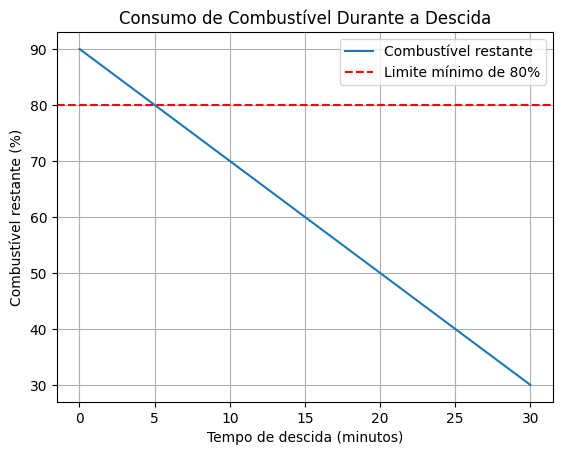

In [15]:
exibir_grafico_combustivel()

In [16]:
print("\n" + "=" * 94)
print(" " * 39 + "FIM DA OPERAÇÃO")
print("=" * 94)


                                       FIM DA OPERAÇÃO


---
## 📝 Conclusão

| Estrutura / Algoritmo | Papel no sistema | Complexidade |
|---|---|---|
| Fila (FIFO) | Atende os módulos na ordem da fila de prioridade | — |
| Pilha (LIFO) | Histórico com o evento mais recente no topo | — |
| Selection Sort | Prioriza os módulos mais urgentes | $O(n^2)$ |
| Insertion Sort | Prepara a lista para busca binária | $O(n^2)$ |
| Busca linear | Localiza módulo na lista original | $O(n)$ |
| Busca binária | Localiza módulo na lista ordenada | $O(\log n)$ |
| Lógica AND | Garante que o pouso só ocorra com todas as condições seguras | — |
